# Data Science Salaries 2023 — Exploratory Analysis

This Notebook is inspired by Kaggle User Panmie`s DS Salary Notebook. <br>
Loading the raw dataset and taking a first look.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
DATA_DIR = Path.cwd().parent / "data"
RAW_PATH = DATA_DIR / "raw" / "ds_salaries.csv"

df = pd.read_csv(RAW_PATH)
df.shape

(3755, 11)

In [4]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [5]:
# 3755 entries no missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 322.8 KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,3755.0,NaN,NaN,NaN,2022.373635,0.691448,2020.0,2022.0,2022.0,2023.0,2023.0
experience_level,3755,4,SE,2516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,3755,4,FT,3718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,3755,93,Data Engineer,1040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,3755.0,NaN,NaN,NaN,190695.571771,671676.500508,6000.0,100000.0,138000.0,180000.0,30400000.0
salary_currency,3755,20,USD,3224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,3755.0,NaN,NaN,NaN,137570.38988,63055.625278,5132.0,95000.0,135000.0,175000.0,450000.0
employee_residence,3755,78,US,3004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,3755.0,NaN,NaN,NaN,46.271638,48.58905,0.0,0.0,0.0,100.0,100.0
company_location,3755,72,US,3040,NaN,NaN,NaN,NaN,NaN,NaN,NaN


No missing values in the dataset. Check for duplicates.

In [7]:
# Handle duplicates
duplicate_rows_data = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (1171, 11)


In [8]:
# .describe had issues describing the unique values of some features
# Loop over features to count distinct values
for column in df.columns:
    num_distinct_values = len(df[column].unique())
    print(f"{column}: {num_distinct_values} distinct values")



work_year: 4 distinct values
experience_level: 4 distinct values
employment_type: 4 distinct values
job_title: 93 distinct values
salary: 815 distinct values
salary_currency: 20 distinct values
salary_in_usd: 1035 distinct values
employee_residence: 78 distinct values
remote_ratio: 3 distinct values
company_location: 72 distinct values
company_size: 3 distinct values


In [9]:
# Rename some entries for better understanding
df['experience_level'] = df['experience_level'].replace({
    'SE': 'Senior',
    'EN': 'Entry level',
    'EX': 'Executive level',
    'MI': 'Mid level',
})

df['employment_type'] = df['employment_type'].replace({
    'FL': 'Freelancer',
    'CT': 'Contractor',
    'FT' : 'Full-time',
    'PT' : 'Part-time'
})
df['company_size'] = df['company_size'].replace({
    'S': 'SMALL',
    'M': 'MEDIUM',
    'L' : 'LARGE',
})
df['remote_ratio'] = df['remote_ratio'].astype(str)
df['remote_ratio'] = df['remote_ratio'].replace({
    '0': 'On-Site',
    '50': 'Half-Remote',
    '100' : 'Full-Remote',
})

In [10]:
# Clustering the job titles into broader categories 
def assign_broader_category(job_title):
    data_engineering = ["Data Engineer", "Data Analyst", "Analytics Engineer", "BI Data Analyst", "Business Data Analyst", "BI Developer", "BI Analyst", "Business Intelligence Engineer", "BI Data Engineer", "Power BI Developer"]
    data_scientist = ["Data Scientist", "Applied Scientist", "Research Scientist", "3D Computer Vision Researcher", "Deep Learning Researcher", "AI/Computer Vision Engineer"]
    machine_learning = ["Machine Learning Engineer", "ML Engineer", "Lead Machine Learning Engineer", "Principal Machine Learning Engineer"]
    data_architecture = ["Data Architect", "Big Data Architect", "Cloud Data Architect", "Principal Data Architect"]
    management = ["Data Science Manager", "Director of Data Science", "Head of Data Science", "Data Scientist Lead", "Head of Machine Learning", "Manager Data Management", "Data Analytics Manager"]
    
    if job_title in data_engineering:
        return "Data Engineering"
    elif job_title in data_scientist:
        return "Data Science"
    elif job_title in machine_learning:
        return "Machine Learning"
    elif job_title in data_architecture:
        return "Data Architecture"
    elif job_title in management:
        return "Management"
    else:
        return "Other"

# Apply the function to the 'job_title' column and create a new column 'job_category'
df['job_category'] = df['job_title'].apply(assign_broader_category)

In order to compare salaries accurately over time, we need to adjust them based with inflation rates in mind.
The plan is to define Inflation rates, but for 72 countries this would be a lot. Lets figure out which countries are mostly represented.

In [11]:
loc_dist = (
    df["company_location"]
    .value_counts()                              # counts, already sorted desc
    .rename_axis("company_location")
    .to_frame("count")
    .assign(
        share_pct=lambda d: (d["count"] / len(df) * 100).round(2),
        cumulative_pct=lambda d: (d["count"].cumsum() / len(df) * 100).round(2),
    )
)

loc_dist.head(10)

,count,share_pct,cumulative_pct
company_location,,,
US,3040,80.96,80.96
GB,172,4.58,85.54
CA,87,2.32,87.86
ES,77,2.05,89.91
IN,58,1.54,91.45
DE,56,1.49,92.94
FR,34,0.91,93.85
BR,15,0.40,94.25
AU,14,0.37,94.62


The US has by far the largest share of companies listed. Lets give credit to kaggle user "rrrrrrita" and use their defined inflation rates for the us and globally.

In [12]:
# Inflation rates
us_inflation_rates = {2019: 0.0181, 2020: 0.0123, 2021: 0.0470, 2022: 0.065}
global_inflation_rates = {2019: 0.0219, 2020: 0.0192, 2021: 0.0350, 2022: 0.088}

# Function to adjust salary
def adjust_salary(row):
    year = row['work_year']
    original_salary = row['salary_in_usd']
    currency = row['salary_currency']

    if year == 2023:
        return original_salary

    adjusted_salary = original_salary
    for y in range(year, 2023):
        if currency == 'USD':
            inflation_rate = us_inflation_rates[y]
        else:
            inflation_rate = global_inflation_rates[y]

        adjusted_salary *= (1 + inflation_rate)

    return adjusted_salary

# Apply the function to the dataset
df['adjusted_salary'] = df.apply(adjust_salary, axis=1)


Let us analyse the data and visualise it as suggested by Panmie. 

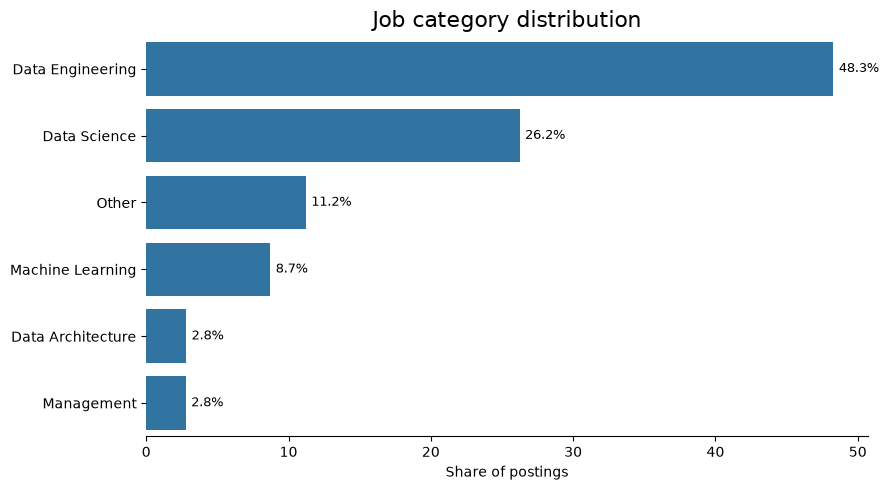

In [13]:
# 1. Relative distribution of job categories in the dataset
category_share = df["job_category"].value_counts(normalize=True).mul(100)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x=category_share.values,
    y=category_share.index,
    legend=False,
    ax=ax,
)

# value on each bar instead of a y-grid
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=4, fontsize=9)

ax.set_title("Job category distribution", fontsize=16)
ax.set_xlabel("Share of postings")
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
sns.despine(left=True)

fig.tight_layout()
plt.show()

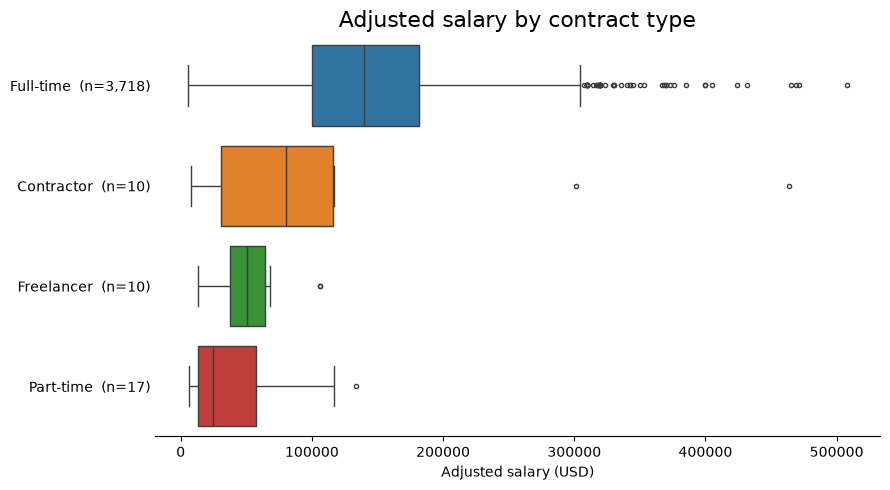

In [14]:
# 2. Adjusted salary distribution over different contract types
counts = df["employment_type"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="adjusted_salary",
    y="employment_type",
    hue="employment_type",
    fliersize=3,
    ax=ax,
)

# group size next to each label
labels = [t.get_text() for t in ax.get_yticklabels()]
ax.set_yticks(range(len(labels)), [f"{t}  (n={counts[t]:,})" for t in labels])

ax.set_title("Adjusted salary by contract type", fontsize=16)
ax.set_xlabel("Adjusted salary (USD)")
ax.tick_params(axis="y", length=0)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
sns.despine(left=True)

fig.tight_layout()
plt.show()


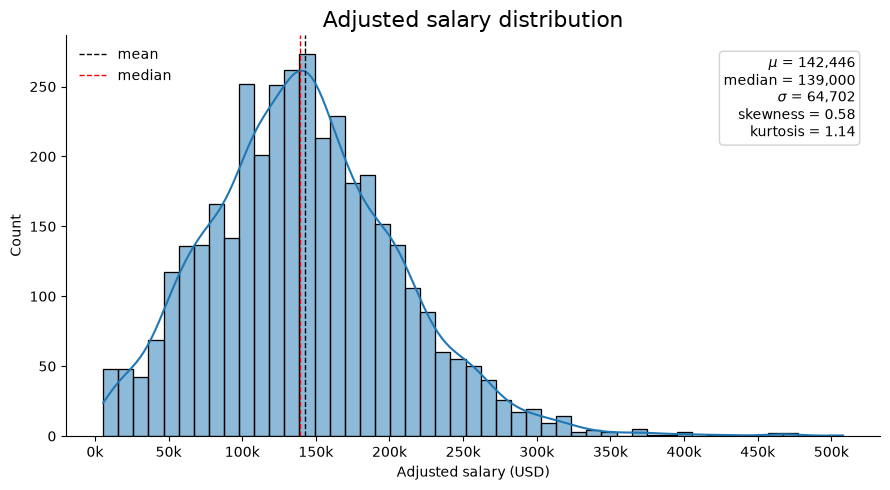

In [16]:
# 3. Salary frequency
salary = df["adjusted_salary"]
mu, median, sigma, skew, kurt = (
    salary.mean(), salary.median(), salary.std(), salary.skew(), salary.kurt()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x="adjusted_salary", kde=True, ax=ax)

ax.xaxis.set_major_locator(plt.MultipleLocator(50_000))
ax.xaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")

ax.axvline(mu, linestyle="--", linewidth=1, color="black", label="mean")
ax.axvline(median, linestyle="--", linewidth=1, color="red", label="median")
ax.legend(loc="upper left", frameon=False)

ax.text(
    0.97, 0.95,
    f"$\\mu$ = {mu:,.0f}\nmedian = {median:,.0f}\n$\\sigma$ = {sigma:,.0f}\n"
    f"skewness = {skew:.2f}\nkurtosis = {kurt:.2f}",
    transform=ax.transAxes, ha="right", va="top", fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="lightgray"),
)

ax.set_title("Adjusted salary distribution", fontsize=16)
ax.set_xlabel("Adjusted salary (USD)")
ax.set_ylabel("Count")
sns.despine()

fig.tight_layout()
plt.show()


**Reading the distribution**

- **σ (standard deviation)** — the typical distance of a salary from the mean.
  Roughly two thirds of salaries fall within μ ± σ, i.e. between ~75k and ~200k USD.
  A σ of ~63k against a μ of ~138k says pay is spread widely: the same job family
  covers a 2–3× range.

- **Skewness** — whether the distribution leans one way. 0 is symmetric; positive
  means a long tail to the right (a few very high salaries pull the mean above the
  median), negative means a tail to the left. Salaries are almost always positively
  skewed, and this dataset is no exception (~0.5). It's a reason to prefer the
  median over the mean when quoting a "typical" salary.

- **Kurtosis** — how heavy the tails are relative to a normal distribution. We
  report *excess* kurtosis, so 0 = normal. Positive means more mass in the tails
  and a sharper peak (extreme values are more common than a bell curve would
  predict); negative means flatter, with fewer extremes. Here it's mildly positive
  (~0.8): most salaries cluster tightly, with a modest number of outliers well
  above 300k.

Taken together: a right-leaning, slightly peaked distribution with a fat upper tail.
